# **Data Understanding**

## Objectives

* Answer business requirement 1:
  * The client is interested in discovering how the house attributes correlate with the sale price. Therefore, the client expects data visualisations of the correlated variables against the sale price to show that.

## Inputs

* outputs/datasets/collection/house_prices 

## Outputs

* generate code that answers BR1 and can be used to build the Streamlit App 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/heritage-housing-issues-milestone/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/heritage-housing-issues-milestone'

# Load Data

In [4]:
import pandas as pd
df = pd.read_csv(f"outputs/datasets/collection/house_prices")
df.head(5)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,642,Unf,1998.0,...,9550,60.0,0.0,35,5,7,756,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,836,RFn,2000.0,...,14260,84.0,350.0,84,5,8,1145,2000,2000,250000


## Data Exploration

We will generate a Profile Report, to visualise the data and help us examine the data.

In [ ]:
from ydata_profiling import ProfileReport
pandas_report = ProfileReport(df=df, minimal=True)
pandas_report.to_notebook_iframe()

---

## Sales Price - Target Visualisation

It is helpful to explore our target Sales Price, to better understand the nature and distribution of this variable. 

We see that the majority of properties sold for between 100,000 and 200,000. Notably there are outliers in the distribution, leading to right-skewed data.

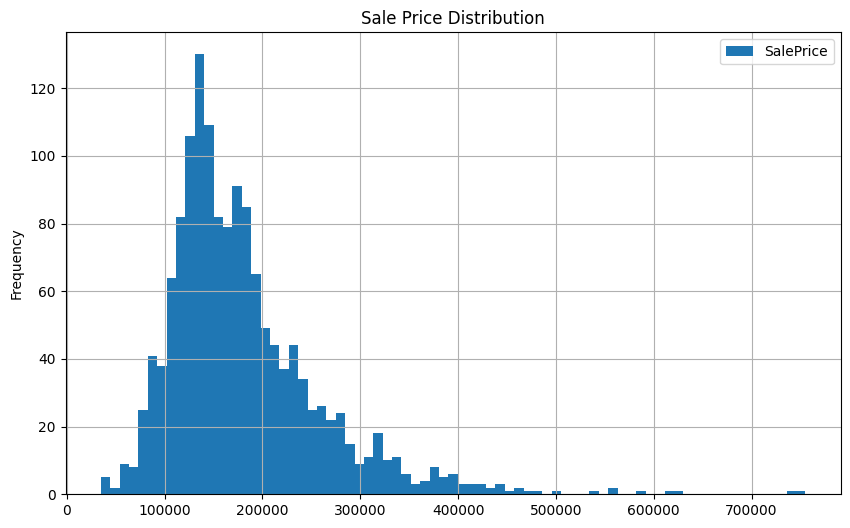

In [8]:
import matplotlib.pyplot as plt

df.plot(kind='hist', y='SalePrice', bins=75, figsize=(10,6), grid = 'True', title='Sale Price Distribution')
plt.show()

# Correlation Study

Since we have four categorical variables, we will use Ordinal Encoder to transform them to numerical values. This is a necessary step before running our correlation study, since the method requires variables as numbers.

In ordinal encoding, each unique category value is assigned an integer value. They have a natural ordered relationship, as opposed to One Hot encoding where no ordinal relationship exists.

In [11]:
from feature_engine.encoding import OrdinalEncoder


encoder = OrdinalEncoder(
    encoding_method='arbitrary',
    variables=['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish'],
    missing_values='ignore'
)


df_encoded = encoder.fit_transform(df)
print(df_encoded.shape)
df_encoded.head(5)

(1460, 22)


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,0.0,706,0.0,150,548,0.0,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,1.0,978,1.0,284,460,0.0,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,2.0,486,0.0,434,608,0.0,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500
3,961,NaN,NaN,0.0,216,1.0,540,642,1.0,1998.0,...,9550,60.0,0.0,35,5,7,756,1915,1970,140000
4,1145,NaN,4.0,3.0,655,0.0,490,836,0.0,2000.0,...,14260,84.0,350.0,84,5,8,1145,2000,2000,250000


Due to the skewness of the data, we have opted to use Spearman Correlation over Pearson. Spearman is more appropriate to handle skewed data with extreme outliers, such as our dataset.

In [13]:
spearman_corr = df_encoded.corr(method='spearman', numeric_only=True)['SalePrice'].sort_values(key=abs, ascending=False)
spearman_corr

SalePrice       1.000000
OverallQual     0.809829
GrLivArea       0.731310
YearBuilt       0.652682
GarageArea      0.649379
TotalBsmtSF     0.602725
GarageYrBlt     0.593788
1stFlrSF        0.575408
YearRemodAdd    0.571159
OpenPorchSF     0.477561
LotArea         0.456461
MasVnrArea      0.421309
BsmtFinType1   -0.414775
LotFrontage     0.409076
KitchenQual    -0.352791
BsmtFinSF1      0.301871
2ndFlrSF        0.298809
BsmtExposure    0.261157
BedroomAbvGr    0.229527
BsmtUnfSF       0.185197
OverallCond    -0.129325
GarageFinish    0.060662
Name: SalePrice, dtype: float64

## Observations from Correlation Methods

From the above studies, we draw the following observations:
* Two variables, OverallQual and GrLivArea, show a strong correlation with SalesPrice.
* Seven variables (YearBuilt, GarageArea, TotalBsmtSF, GarageYrBlt, 1stFlrSF, YearRemodAdd and OpenPorchSF) show a moderate correlation of 0.48 to 0.65.
* There are a number of variables showing a weak but potentially useful level of correlation for the purposes of Machine Learning.



## Heatmap

We have included a heatmap to help visualise the correlation between the top 10 correlated values and Sales Price.

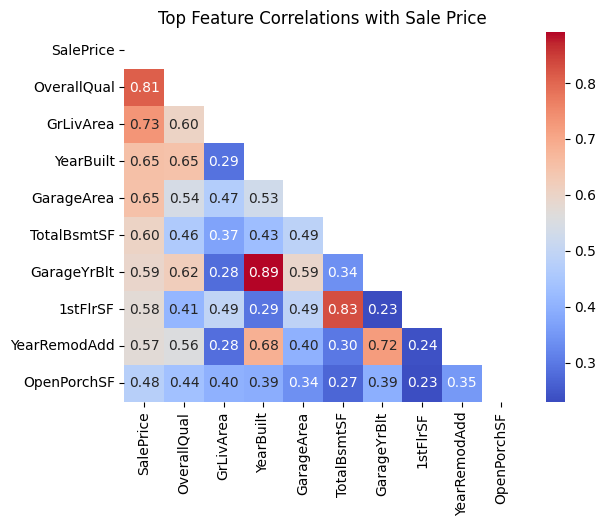

In [14]:
# Generate heatmap for spearman correlation
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

top_features = spearman_corr.index[:10]

# Calculate correlation matrix
df_corr = df_encoded[top_features].corr(method='spearman')

# Create mask for upper triangle
mask = np.zeros_like(df_corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
plt.title('Top Feature Correlations with Sale Price')
plt.show()



---

## Scatter Plots

We have displayed the data on scatter plots for further visualisation and understanding.

These will help us explore the relationships between each of our top features with Sale Price.

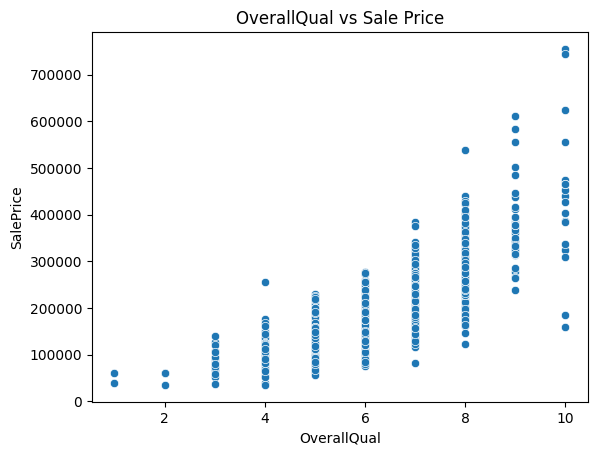

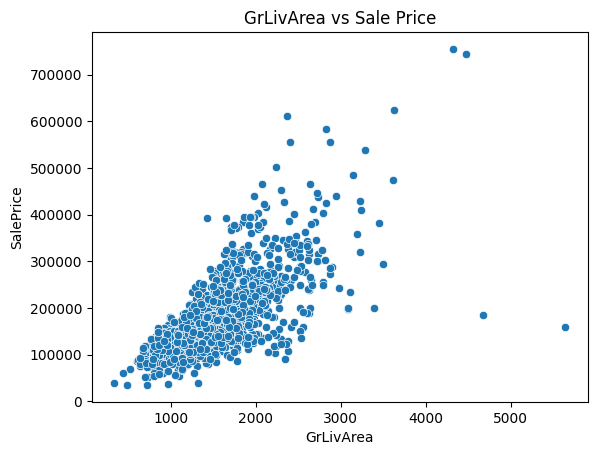

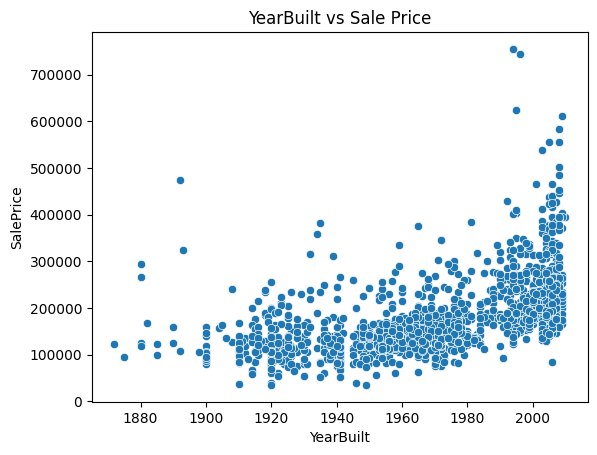

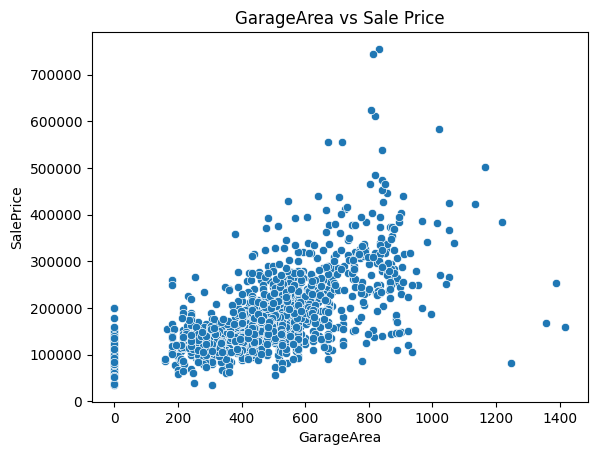

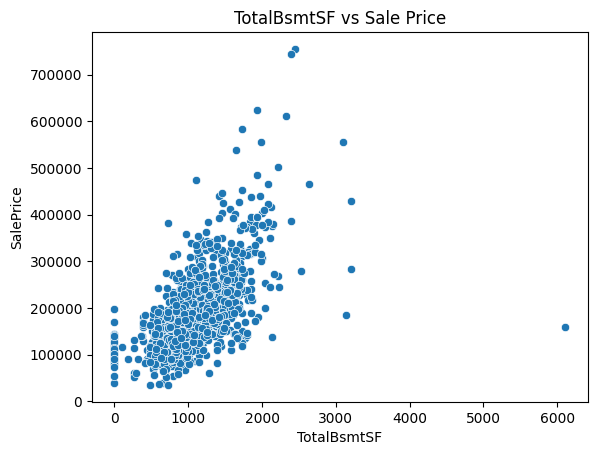

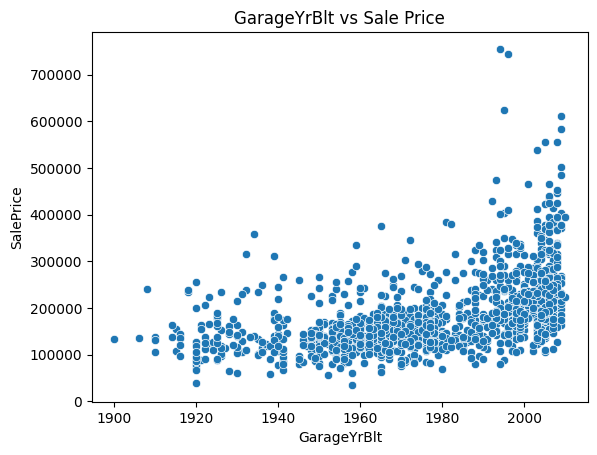

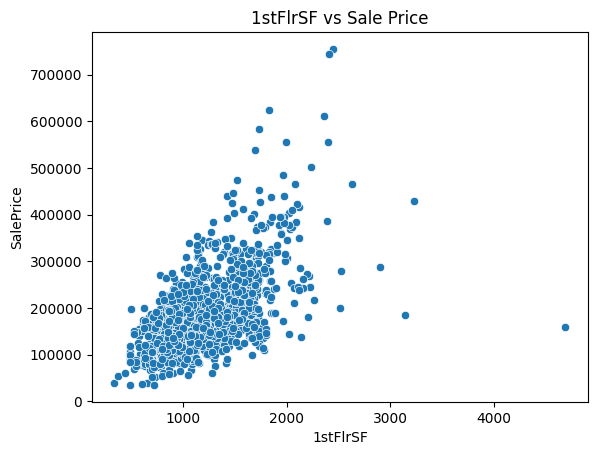

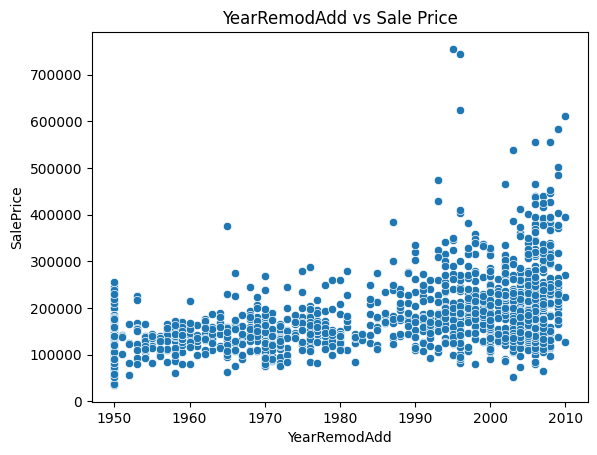

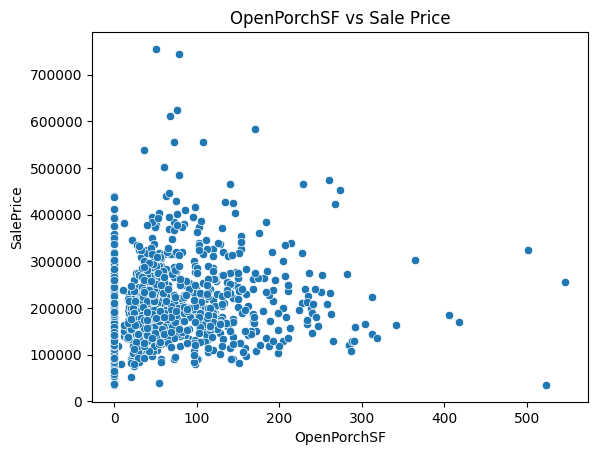

In [18]:
import seaborn as sns

for feature in top_features[1:]:
    sns.scatterplot(data=df, x=feature, y='SalePrice')
    plt.title(f'{feature} vs Sale Price')
    plt.show()


## Box Plots

To explore the relationship of the categorical variables with Sale Price, we have included 4 box plots.

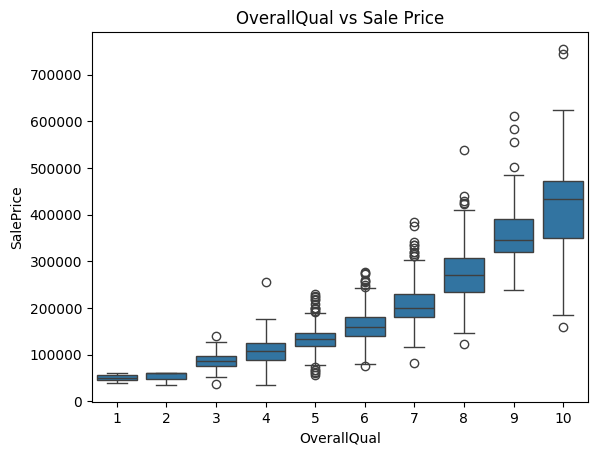

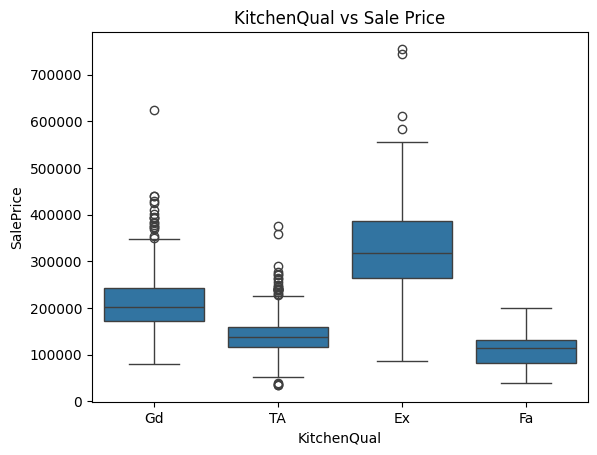

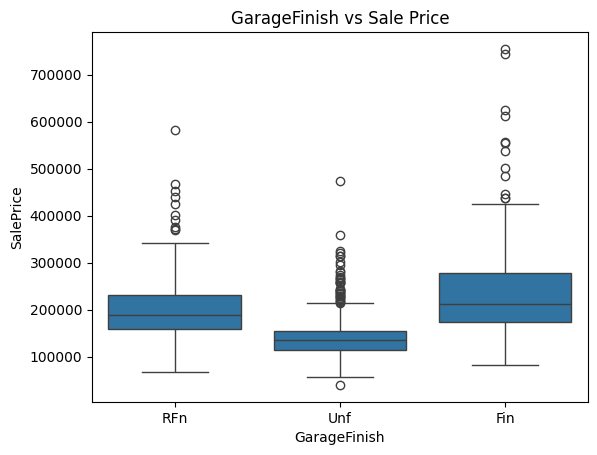

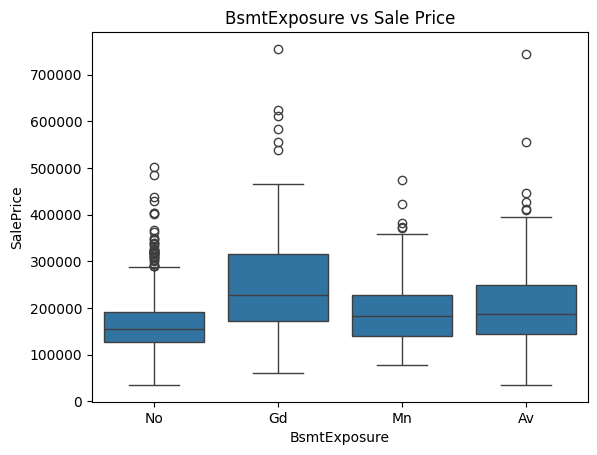

In [19]:
categorical_features = ['OverallQual', 'KitchenQual', 'GarageFinish', 'BsmtExposure']

for feature in categorical_features:
    sns.boxplot(data=df, x=feature, y='SalePrice')
    plt.title(f'{feature} vs Sale Price')
    plt.show()


---

# Conclusions

